In [1]:
import os
import numpy as np
import pandas as pd

import geopandas as gpd

import cmocean.cm as cmo

import xarray as xr
import rasterio
import rasterio.plot as rplt
from affine import Affine

from shapely.geometry import LineString, Point


import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from mpl_toolkits.axes_grid1 import make_axes_locatable

import app


In [2]:
base_directory = r"D:\PhD\21_Experiments\TidesDamageDriver"
drainages_folder = os.path.join(
    base_directory, "02_processed", "03_drainages"
)
coastline_folder = os.path.join(
    base_directory, "01_raw", "greene2022_coastlines"
)
iceshelf_folder = os.path.join(
    base_directory, "01_raw", "greene2022_iceshelves"
)
add_path = os.path.join(
    base_directory, "01_raw", "high_res_coastline", "add_coastline_high_res_line_v7_6.shp"
)
lai_path = os.path.join(
    base_directory, "01_raw", "lai2020_vulnerability", "vulnerable.nc"
)
fuerst_path = os.path.join(
    base_directory, "01_raw", "fuerst2016_psi", "psi.nc"
)

grid_path = os.path.join(
    base_directory, "01_raw", "grid", "ne_110m_graticules_1.shp"
)
tides_folder = os.path.join(
    base_directory, "01_raw", "tides_CATS2008"
)
data_dmg_merged_folder = os.path.join(
    base_directory, "03_cleaned", "dmg_merged"
)
data_dmg_folder = os.path.join(
    base_directory, "03_cleaned", "dmg_resampled"
)
data_dmg_masked_folder = os.path.join(
    base_directory, "03_cleaned", "dmg_resampled_masked"
)
figure_folder = os.path.join(
    base_directory, "figures"
)

In [3]:
years = [2016, 2018, 2019, 2020]
xmin = 2.50e6
xmax = 2.77e6
ymax = -0.215e6
ymin = -0.591e6
vertical_line = LineString([(xmin, ymin), (xmin, ymax)])

In [4]:
all_coastline_files = os.listdir(coastline_folder)
coastlines = [
    gpd.read_file(os.path.join(coastline_folder, f)).cx[xmin:xmax, ymin:ymax]
    for f in all_coastline_files
    if f.endswith(".shp") and any([str(s) in f for s in years])
]
buffer = 6e3
coastlines_buffer = [c.buffer(buffer) for c in coastlines]

In [5]:
all_iceshelves_files = os.listdir(iceshelf_folder)
iceshelves = [
    gpd.read_file(os.path.join(iceshelf_folder, f)).cx[xmin:xmax, ymin:ymax]
    for f in all_iceshelves_files
    if f.endswith(".shp") and any([str(s) in f for s in years])
]
ice_buffer = 150
for ice in iceshelves:
    ice.geometry = ice.buffer(ice_buffer)
    ice = ice.dissolve()
    ice.geometry = ice.buffer(-ice_buffer)
cmap = mpl.colormaps["cmo.ice"]
ice_colors = cmap(np.linspace(0.2, 0.8, 3))

buffer = 6e3
iceshelves_buffer = [i.buffer(buffer) for i in iceshelves]

In [6]:
add = gpd.read_file(
    add_path
)
add.columns
add["surface"].unique()

shelf_lines = add[add["surface"].isin(["ice shelf and front"])]
grounding_lines = add[
    add["surface"].isin(
        [
            "ice coastline",
            "grounding line",
            "ice rumples",
            "rock against ice shelf",
            "rock coastline",
        ]
    )
]

shelf = shelf_lines.cx[xmin:xmax, ymin:ymax]
grounding_line = grounding_lines.cx[xmin:xmax, ymin:ymax]

In [7]:
grid = gpd.read_file(grid_path)  # https://www.naturalearthdata.com/about/terms-of-use/
grid.to_crs("EPSG:3031", inplace=True)
grid = grid.cx[xmin:xmax, ymin:ymax]

grid_filtered = gpd.GeoDataFrame(grid[grid["degrees"].isin([65, 66, 100, 95])].cx[xmin: xmax, ymin: ymax])
grid_filtered_S = grid_filtered.query("direction == 'S'")
grid_filtered_E = grid_filtered.query("direction == 'E'")

label_points_grid = []

for idx, row in grid_filtered.iterrows():
    line = row.geometry
    intersection = line.intersection(vertical_line)

    if not intersection.is_empty:
        if intersection.geom_type == "Point":
            x_int, y_int = intersection.x, intersection.y
            if ymin <= y_int <= ymax:
                label_points_grid.append({
                    "label": row["display"],
                    "x": x_int,
                    "y": y_int
                })
        elif intersection.geom_type in ["MultiPoint", "GeometryCollection"]:
            for geom in intersection.geoms:
                if geom.geom_type == "Point":
                    x_int, y_int = geom.x, geom.y
                    if ymin <= y_int <= ymax:
                        label_points_grid.append({
                            "label": row["display"],
                            "x": x_int,
                            "y": y_int
                        })
grid.head()

,degrees,direction,display,scalerank,dd,geometry
154,65,S,65 S,6,-65,"LINESTRING (-2.112e-9 -2758494.765, 161.696 -2..."
155,66,S,66 S,6,-66,"LINESTRING (2.365 -2644909.451, 155.038 -26449..."
156,67,S,67 S,6,-67,"LINESTRING (2.264 -2531747.008, 148.404 -25317..."
256,103,E,103 E,6,103,"LINESTRING (7.141 -1.648, 52938.639 -12219.281..."
257,102,E,102 E,6,102,"LINESTRING (7.169 -1.523, 53143.83 -11293.522,..."


In [8]:
dmgs = []
dmgs_transforms = []
dmgs_meta = []
for i_year, year in enumerate(years):
    path = os.path.join(
        data_dmg_folder, f'{year}', f'S1_{year}1101_{year}1110_3000m_dmg.tif'
    )
    with rasterio.open(path) as src:
        raster = src.read(1)
        meta = src.meta.copy()
        transform = src.transform

        masked, masked_transform = app.dmg.tiffiles.mask_dataset(
            raster, transform, iceshelves_buffer[i_year], mode="shape", filled=False
        )
        masked = (masked / np.nanmax(masked)).copy()

    dmgs.append(masked)
    dmgs_transforms.append(masked_transform)
    dmgs_meta.append(meta)

In [9]:
dmgs0 = []
dmgs0_transforms = []
dmgs0_meta = []
for i_year, year in enumerate(years):
    path = os.path.join(
        data_dmg_merged_folder, f'{year}', f'S1_{year}1101_{year}1110_30m_output_10px_dmg.tif'
    )
    with rasterio.open(path) as src:
        raster = src.read(1)
        meta = src.meta.copy()
        transform = src.transform

        masked, masked_transform = app.dmg.tiffiles.mask_dataset(
            raster, transform, iceshelves_buffer[i_year], mode="shape", filled=False
        )
        masked = (masked / np.nanmax(masked)).copy()

    dmgs0.append(masked)
    dmgs0_transforms.append(masked_transform)
    dmgs0_meta.append(meta)

In [10]:
acts = []
acts_transforms = []
acts_meta = []
for i_year, year in enumerate(years):
    path = os.path.join(
        data_dmg_folder, f'{year}', f'S1_{year}1101_{year}1110_3000m_act.tif'
    )
    with rasterio.open(path) as src:
        raster = src.read(1)
        meta = src.meta.copy()
        transform = src.transform

        #raster[raster == 0] = np.nan
        masked, masked_transform = app.dmg.tiffiles.mask_dataset(
            raster, transform, iceshelves_buffer[i_year], mode="shape", filled=False
        )
        #masked = masked
        masked = (masked / np.nanmax(masked)).copy()
    acts.append(masked)
    acts_transforms.append(masked_transform)
    acts_meta.append(meta)

In [11]:
acts0 = []
acts0_transforms = []
acts0_meta = []
for i_year, year in enumerate(years):
    path = os.path.join(
        data_dmg_merged_folder, f'{year}', f'S1_{year}1101_{year}1110_30m_output_10px_act.tif'
    )
    with rasterio.open(path) as src:
        raster = src.read(1)
        meta = src.meta.copy()
        transform = src.transform

        #raster[raster == 0] = np.nan
        masked, masked_transform = app.dmg.tiffiles.mask_dataset(
            raster, transform, iceshelves_buffer[i_year], mode="shape", filled=False
        )
        #masked = masked
        masked = (masked / np.nanmax(masked)).copy()
    acts0.append(masked)
    acts0_transforms.append(masked_transform)
    acts0_meta.append(meta)

In [12]:
emaxs = []
emaxs_transforms = []
emaxs_meta = []
for i_year, year in enumerate(years):
    path = os.path.join(
        data_dmg_folder, f'{year}', f'S1_{year}1101_{year}1110_3000m_emax.tif'
    )
    with rasterio.open(path) as src:
        raster = src.read(1)
        meta = src.meta.copy()
        transform = src.transform

        raster[raster == 0] = np.nan
        masked, masked_transform = app.dmg.tiffiles.mask_dataset(
            raster, transform, iceshelves_buffer[i_year], mode="shape", filled=False
        )
        #masked = masked
        #masked = (masked / np.nanmax(masked)).copy()
    emaxs.append(masked)
    emaxs_transforms.append(masked_transform)
    emaxs_meta.append(meta)

In [13]:
emaxs0 = []
emaxs0_transforms = []
emaxs0_meta = []
for i_year, year in enumerate(years):
    path = os.path.join(
        data_dmg_merged_folder, f'{year}', f'S1_{year}1101_{year}1110_30m_output_10px_emax.tif'
    )
    with rasterio.open(path) as src:
        raster = src.read(1)
        meta = src.meta.copy()
        transform = src.transform

        # raster[raster == 0] = np.nan
        masked, masked_transform = app.dmg.tiffiles.mask_dataset(
             raster, transform, iceshelves_buffer[i_year], mode="shape", filled=False
        )
        # masked = masked
        masked = (masked / np.nanmax(masked)).copy()
    emaxs0.append(masked)
    emaxs0_transforms.append(masked_transform)
    emaxs0_meta.append(meta)

In [14]:
crevS = []
crevS_transforms = []
crevS_meta = []
for i_year, year in enumerate(years):
    path = os.path.join(
        data_dmg_folder, f'{year}', f'S1_{year}1101_{year}1110_3000m_crevSig.tif'
    )
    with rasterio.open(path) as src:
        raster = src.read(1)
        meta = src.meta.copy()
        transform = src.transform

        raster[raster == 0] = np.nan
        masked, masked_transform = app.dmg.tiffiles.mask_dataset(
            raster, transform, iceshelves_buffer[i_year], mode="shape", filled=False
        )
        #masked = masked
        #masked = (masked / np.nanmax(masked)).copy()
    crevS.append(masked)
    crevS_transforms.append(masked_transform)
    crevS_meta.append(meta)

In [15]:
fuerst = xr.open_dataset(fuerst_path, engine="netcdf4")
da = fuerst["PSI"]
da = da.rio.write_crs("EPSG:3031", inplace=True)
fuerst_raster = da.values  # 2D NumPy array
fuerst_transform = da.rio.transform()  # Affine transform from xarray
fuerst_raster_1 = fuerst_raster.copy()
fuerst_raster_1[fuerst_raster != 1] = np.nan

fuerst_color = "#0169fa"
cmap_fuerst_color = ListedColormap([fuerst_color])

In [16]:
lai = xr.open_dataset(lai_path, engine="netcdf4")
da = lai["vulnerable"]
da = da.rio.write_crs("EPSG:3031", inplace=True)
lai_raster = da.values  # 2D NumPy array
lai_transform = da.rio.transform()  # Affine transform from xarray
lai_raster_0 = lai_raster.copy()
lai_raster_0[lai_raster != 0] = np.nan
lai_raster_1 = lai_raster.copy()
lai_raster_1[lai_raster != 1] = np.nan

lai_vulnerable_color = "#a31430"
lai_no_color = "#150016"
cmap_lai_vulnerable_color = ListedColormap([lai_vulnerable_color])
cmap_lai_no_color = ListedColormap([lai_no_color])
cmap_lai_no_color = ListedColormap([lai_no_color])

In [17]:
total_width = 18 / 2.54
year_show = 2019
i_year_show = years.index(year_show)

In [18]:
gird_label_font = 5
cmap_gray = app.lakes.plotting.truncate_colormap(plt.get_cmap("cmo.gray_r"), 0.0, 0.8)
CMAP_DMG = app.lakes.plotting.truncate_colormap(plt.get_cmap("cmo.amp"), 0.0, 1)
CMAP_ACT = app.lakes.plotting.truncate_colormap(plt.get_cmap("cmo.rain"), 0.0, 1)
CMAP_EMAX = app.lakes.plotting.truncate_colormap(plt.get_cmap("cmo.tempo"), 0.0, 1)
CMAP_CREVSIG = app.lakes.plotting.truncate_colormap(plt.get_cmap("cmo.ice"), 0.0, 1)
ss = [30]
ssp = [20]

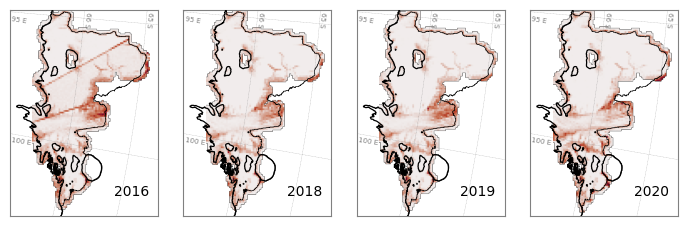

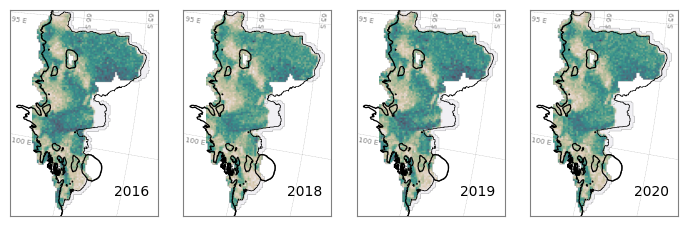

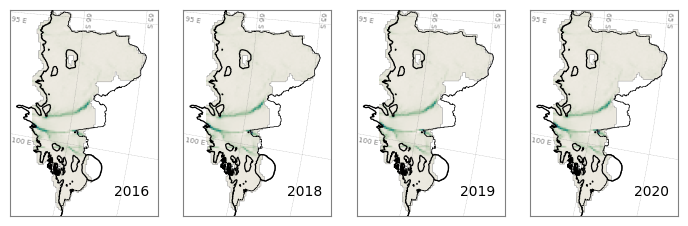

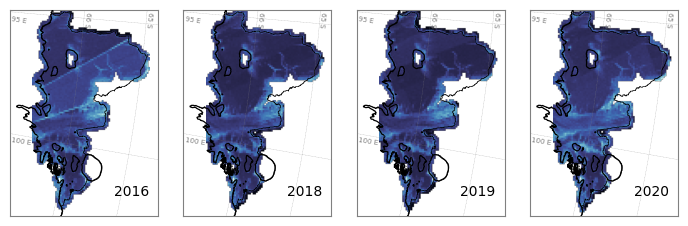

In [19]:
controlled_fraction = 0.4

names = ["dmg", "act", "emax", "crevSig"]
for i_collection, (collection, transforms, cmap) in enumerate(zip(
    [dmgs, acts, emaxs, crevS],
    [dmgs_transforms, acts_transforms, emaxs_transforms, crevS_transforms],
    [CMAP_DMG, CMAP_ACT, CMAP_EMAX, CMAP_CREVSIG])):

    fig, axes = plt.subplots(1, 4, figsize=(total_width, 6 / 2.54))
    for i_year, year in enumerate(years):

        ax = axes.ravel()[i_year]
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)

        grid_filtered.plot(ax=ax, color="gray", linewidth=0.2, alpha=0.8, ls="--", zorder = 15)
        coastlines[i_year].plot(ax=ax, facecolor="none", edgecolor="black", lw=0.5, zorder = 3)
        grounding_line.plot(ax=ax, facecolor="none", edgecolor="black", lw=0.9, zorder = 3)

        if i_collection == 0:
            rplt.show(collection[i_year], transform=transforms[i_year], ax=ax, cmap=cmap, zorder = 1)
        if i_collection == 1:
            rplt.show(collection[i_year], transform=transforms[i_year], ax=ax, cmap=cmap, zorder = 1, alpha =.8) # collection[i_year], alpha=alpha
        else:
            rplt.show(collection[i_year], transform=transforms[i_year], ax=ax, cmap=cmap, zorder = 1)

        # S labels (assume all same Y)
        ys = np.full(len(grid_filtered_S), ymax - 3e3)
        xs = grid_filtered_S.bounds.maxx - 5e3
        labels = grid_filtered_S['degrees'].astype(str) + ' S'

        for x, y, s in zip(xs, ys, labels):
            ax.text(x, y, s, rotation=-96, ha="center", va="top",
                    fontsize=gird_label_font, color="gray", zorder=16)

        # E labels (assume all same Y)
        label_lookup = {l['label']: l['y'] for l in label_points_grid}
        xs = np.full(len(grid_filtered_E), xmin + 2e3)
        ys = grid_filtered_E['display'].map(label_lookup) - 1.5e4
        labels = grid_filtered_E['degrees'].astype(str) + ' E'

        for x, y, s in zip(xs, ys, labels):
            ax.text(x, y, s, rotation=-9, ha="left", va="center",
                    fontsize=gird_label_font, color="gray", zorder=16)

        ax.tick_params(
            axis="both",  # changes apply to the x-axis
            which="both",  # both major and minor ticks are affected
            bottom=False,  # ticks along the bottom edge are off
            top=False,  # ticks along the top edge are off
            left=False,
            right=False,
            labelbottom=False,
            labelleft=False,
        )
        ax.text(x = 0.7, y = 0.1, s=str(year), transform=ax.transAxes)
        
        ax.spines["bottom"].set_color("gray")
        ax.spines["top"].set_color("gray")
        ax.spines["left"].set_color("gray")
        ax.spines["right"].set_color("gray")

    plt.tight_layout()
    plt.savefig(
        os.path.join(figure_folder, f"figure_S2_{names[i_collection]}.png"),
        dpi=300,
    )
    plt.savefig(
        os.path.join(figure_folder, f"figure_S2_{names[i_collection]}.pdf"),
        dpi=300,
    )
    plt.show()